### Pass@k plots for Experiment 5

In [1]:
import os
import pathlib
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
root = "/ptmp/rfechner/out/exp05_rollouts_qwen2.5-7b/"
dirs = os.listdir(root)
dirs = list(filter(lambda x: x.startswith('qwen'), dirs)) # filter out cached files
rollout_paths = {
    d : os.path.join(root, d, 'val_jsonl') for d in dirs
}

In [3]:
rollout_paths

{'qwen2.5_7b__gspo': '/ptmp/rfechner/out/exp05_rollouts_qwen2.5-7b/qwen2.5_7b__gspo/val_jsonl',
 'qwen2.5_7b__entropy_reg': '/ptmp/rfechner/out/exp05_rollouts_qwen2.5-7b/qwen2.5_7b__entropy_reg/val_jsonl',
 'qwen2.5_7b__gtpo': '/ptmp/rfechner/out/exp05_rollouts_qwen2.5-7b/qwen2.5_7b__gtpo/val_jsonl',
 'qwen2.5_7b__drgrpo': '/ptmp/rfechner/out/exp05_rollouts_qwen2.5-7b/qwen2.5_7b__drgrpo/val_jsonl',
 'qwen2.5_7b__grpo-s': '/ptmp/rfechner/out/exp05_rollouts_qwen2.5-7b/qwen2.5_7b__grpo-s/val_jsonl',
 'qwen2.5_7b__grpo': '/ptmp/rfechner/out/exp05_rollouts_qwen2.5-7b/qwen2.5_7b__grpo/val_jsonl',
 'qwen2.5_7b__clip-cov': '/ptmp/rfechner/out/exp05_rollouts_qwen2.5-7b/qwen2.5_7b__clip-cov/val_jsonl',
 'qwen2.5_7b__kl-cov': '/ptmp/rfechner/out/exp05_rollouts_qwen2.5-7b/qwen2.5_7b__kl-cov/val_jsonl',
 'qwen2.5_7b__dapo': '/ptmp/rfechner/out/exp05_rollouts_qwen2.5-7b/qwen2.5_7b__dapo/val_jsonl'}

In [4]:
def pass_at_k(rewards, k):
    """
    Compute pass@k for a list or array of binary rewards.
    Args:
        rewards (list or np.ndarray): Binary vector where 1 = success, 0 = failure.
        k (int): The number of samples considered for pass@k.
    Returns:
        float: Estimated pass@k value.
    """
    rewards = np.array(rewards)
    n = len(rewards)
    c = rewards.sum()
    if c == 0:
        return 0.0
    if n - c < k:
        return 1.0
    return 1.0 - np.prod([(n - c - i) / (n - i) for i in range(k)]) 

In [5]:
def calculate_pass_at_k(data : pd.DataFrame, ks = 2**np.arange(9)):
    pass_at_values = {
        'math500' : [],
        'aime25' : [],
        'brumo25' : [],
        'cmimc25' : [],
        'hmmt25' : []
    }
    def get_key(index : int):
        """
        First 500 are math500,
        next 30 are aime25,
        next 30 are brumo25,
        next 40 are cmimc25,
        last 30 are hmmt25
        """
        if index < 500:
            return 'math500'
        elif index < 530:
            return 'aime25'
        elif index < 560:
            return 'brumo25'
        elif index < 600:
            return 'cmimc25'
        elif index < 630:
            return 'hmmt25'
        else:
            raise ValueError('Index > 630. Did validation set change?')
        
        
    for i, (name, group) in enumerate(data.groupby('input', sort=False)):
        pass_at_values[get_key(i)].append(
            [pass_at_k(rewards=group['reward'], k=k) for k in ks]
        )
    return {k : np.stack(vs).mean(axis=0) for k, vs in pass_at_values.items()}

In [ ]:
RECOMPUTE=False
ks = 2**np.arange(9)
if RECOMPUTE:
    passrates_per_method = {}
    for method, path in rollout_paths.items():
        print('Reading: ', method)
        rollout_files = list(
                            sorted(
                                filter(lambda x: x.endswith('_rollouts.jsonl'), os.listdir(path)),
                                key=lambda x: x.split('_')[0])
                            )
        passrates = {}
        for file in tqdm(rollout_files):
            with open(os.path.join(path, file), 'r') as jsonfile:
                checkpoint_index = file.split('_')[0]
                df = pd.read_json(jsonfile, lines=True)
                pass_at_values = calculate_pass_at_k(df, ks=ks)
                

                passrates[checkpoint_index] = pass_at_values
        passrates_per_method[method] = passrates

    with open(os.path.join(root, 'cache.pickle'), 'wb') as file:
        pickle.dump(passrates_per_method, file)
else:
    with open(os.path.join(root, 'cache.pickle'), 'rb') as file:
        passrates_per_method = pickle.load(file)
    

In [7]:
def plot_pass_rates(passrates_per_method):
    methods = list(passrates_per_method.keys())
    n_methods = len(methods)

    # Collect all dataset names (validation data sources)
    datasets = sorted({
        ds for method_data in passrates_per_method.values()
        for ckpt_data in method_data.values()
        for ds in ckpt_data.keys()
    })
    n_datasets = len(datasets)

    fig, axes = plt.subplots(
        n_datasets, n_methods,
        figsize=(3 * n_methods, 3 * n_datasets),
        sharey='row',
        squeeze=False
    )

    for j, method in enumerate(methods):
        method_data = passrates_per_method[method]

        # Collect all checkpoints and sort numerically
        checkpoints = sorted(method_data.keys(), key=lambda x: int(x))
        n_ckpts = len(checkpoints)
        cmap = plt.get_cmap("viridis")
        colors = [cmap(i / max(1, n_ckpts - 1)) for i in range(n_ckpts)]

        for i, dataset in enumerate(datasets):
            ax = axes[i, j]

            for color, ckpt in zip(colors, checkpoints):
                if dataset not in method_data[ckpt]:
                    continue
                y = np.array(method_data[ckpt][dataset])
                x = np.arange(1, len(y) + 1)
                ax.plot(x, y, color=color, label=f"ckpt {ckpt}")
            if i == 0:
                ax.set_title(method)
            if j == 0:
                ax.set_ylabel(f"{dataset}\npass@k")

            ax.set_xticks(x, ks)
            ax.set_xlabel("k")
            ax.grid(True, alpha=0.3)

            if i == 0:
                # Only show legend once for clarity
                ax.legend(fontsize=8, title="Checkpoint", loc='upper left')

    plt.tight_layout()
    plt.show()


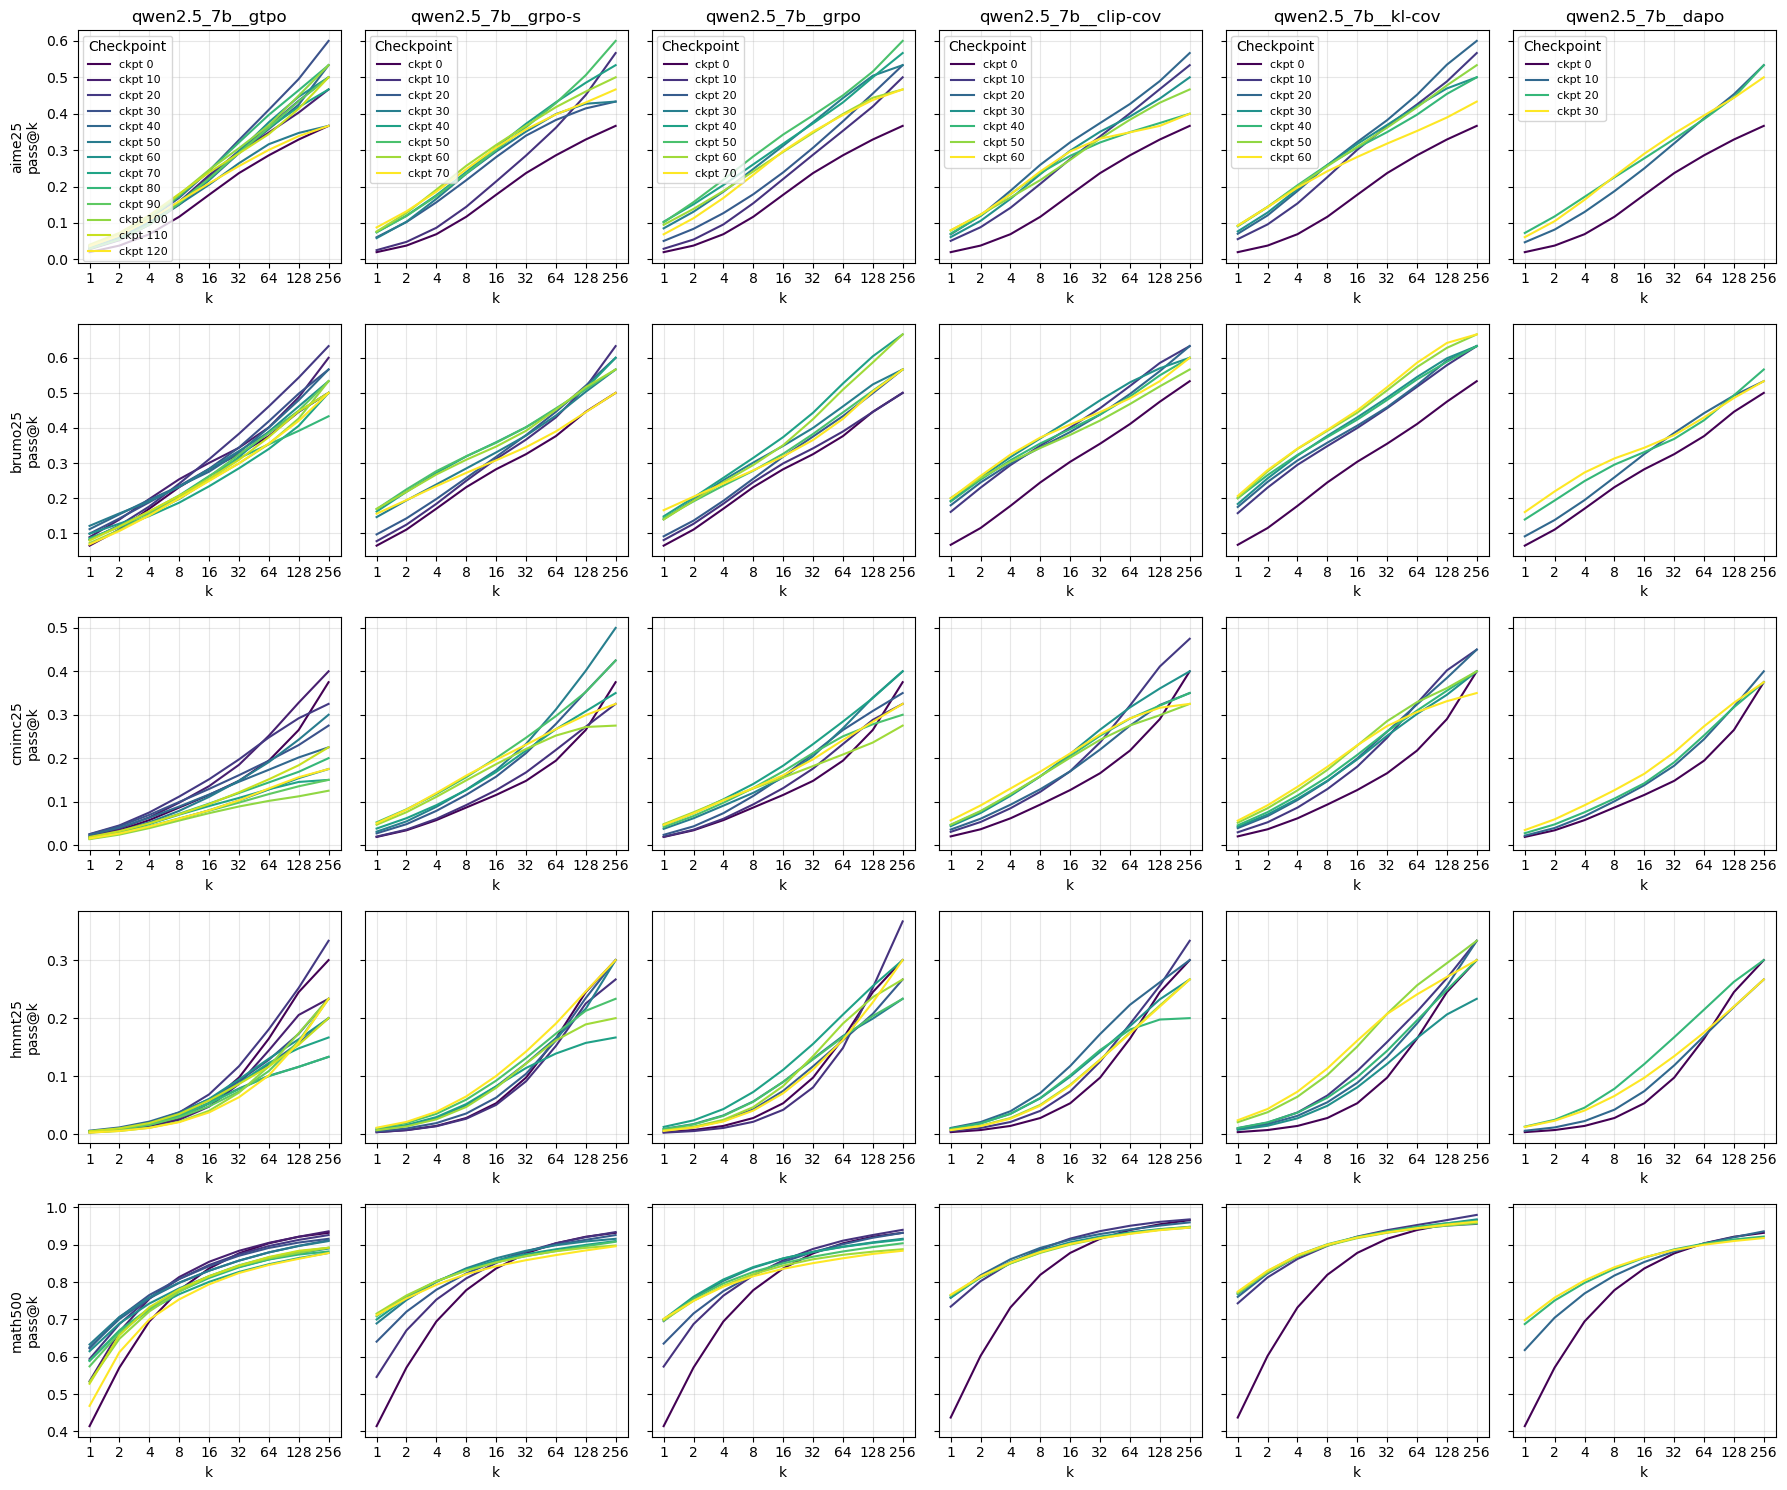

In [8]:
plot_pass_rates(passrates_per_method=passrates_per_method)

### Calculate change in pass@1-rate@256

I have two plots in mind. One:

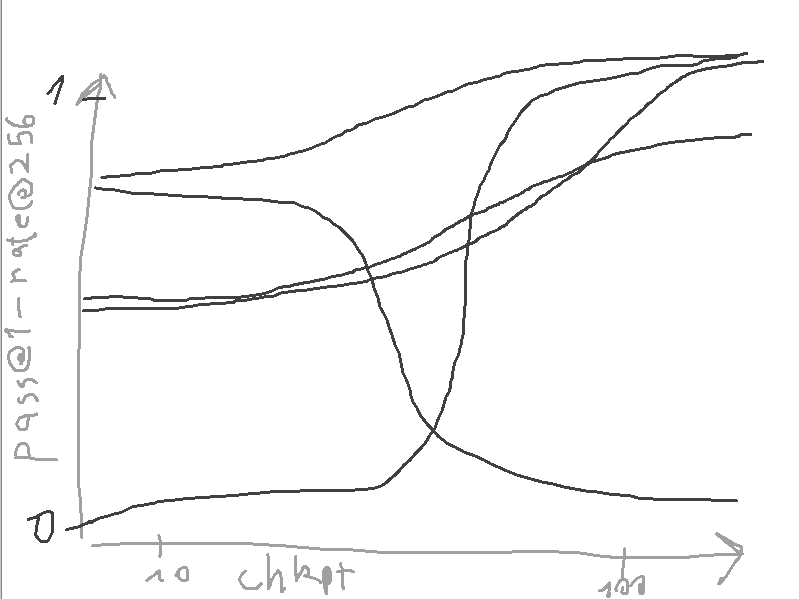

I'd like to plot the pass@1-rate@256 over the course of training *per question*. Does the passrate of these question degenerate steadily? Do we see jumps?

Second:
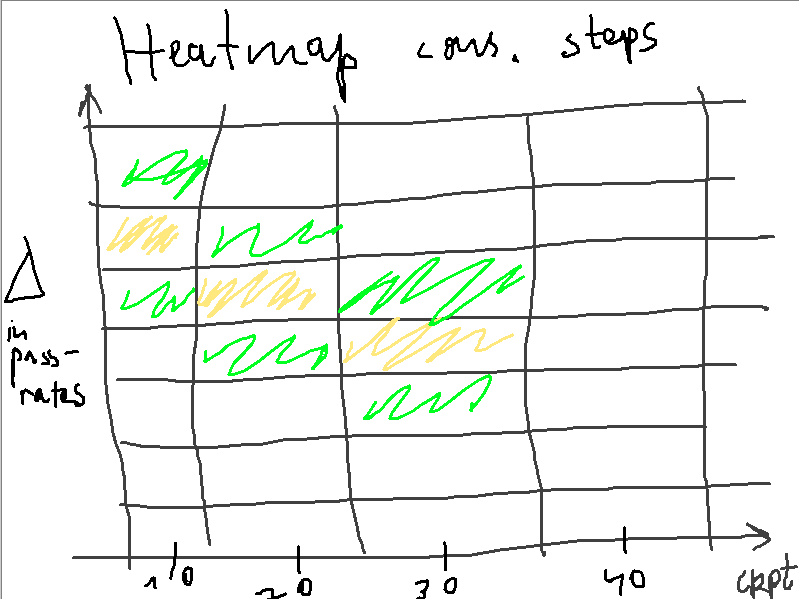


Distribution over the $\Delta$ of passrates between checkpoints.

In [9]:
def calculate_passrate_per_question(data : pd.DataFrame):
    pass_at_values = {
        'math500' : [],
        'aime25' : [],
        'brumo25' : [],
        'cmimc25' : [],
        'hmmt25' : []
    }
    def get_key(index : int):
        """
        First 500 are math500,
        next 30 are aime25,
        next 30 are brumo25,
        next 40 are cmimc25,
        last 30 are hmmt25
        """
        if index < 500:
            return 'math500'
        elif index < 530:
            return 'aime25'
        elif index < 560:
            return 'brumo25'
        elif index < 600:
            return 'cmimc25'
        elif index < 630:
            return 'hmmt25'
        else:
            raise ValueError('Index > 630. Did validation set change?')
        
    for i, (name, group) in enumerate(data.groupby('input', sort=False)):
        pass_at_values[get_key(i)].append(pass_at_k(group['reward'], k=1))
    return {k : np.stack(vs) for k, vs in pass_at_values.items()}

In [10]:
# 1) get the deltas for consecutive steps per question type. We cannot use the previous calculated values, as they've already accumulated over the question dimension.

if RECOMPUTE:
    prs_method_question = {}
    for method, path in rollout_paths.items():
        print('Reading: ', method)
        rollout_files = list(
                            sorted(
                                filter(lambda x: x.endswith('_rollouts.jsonl'), os.listdir(path)),
                                key=lambda x: x.split('_')[0])
                            )
        passrates = {}
        for file in tqdm(rollout_files):
            with open(os.path.join(path, file), 'r') as jsonfile:
                checkpoint_index = file.split('_')[0]
                df = pd.read_json(jsonfile, lines=True)
                prs = calculate_passrate_per_question(df)
                passrates[checkpoint_index] = prs
        prs_method_question[method] = passrates

    with open(os.path.join(root, 'cached-prs_method_question.pickle'), 'wb') as file:
        pickle.dump(prs_method_question, file)
else:
    with open(os.path.join(root, 'cached-prs_method_question.pickle'), 'rb') as file:
        prs_method_question = pickle.load(file)

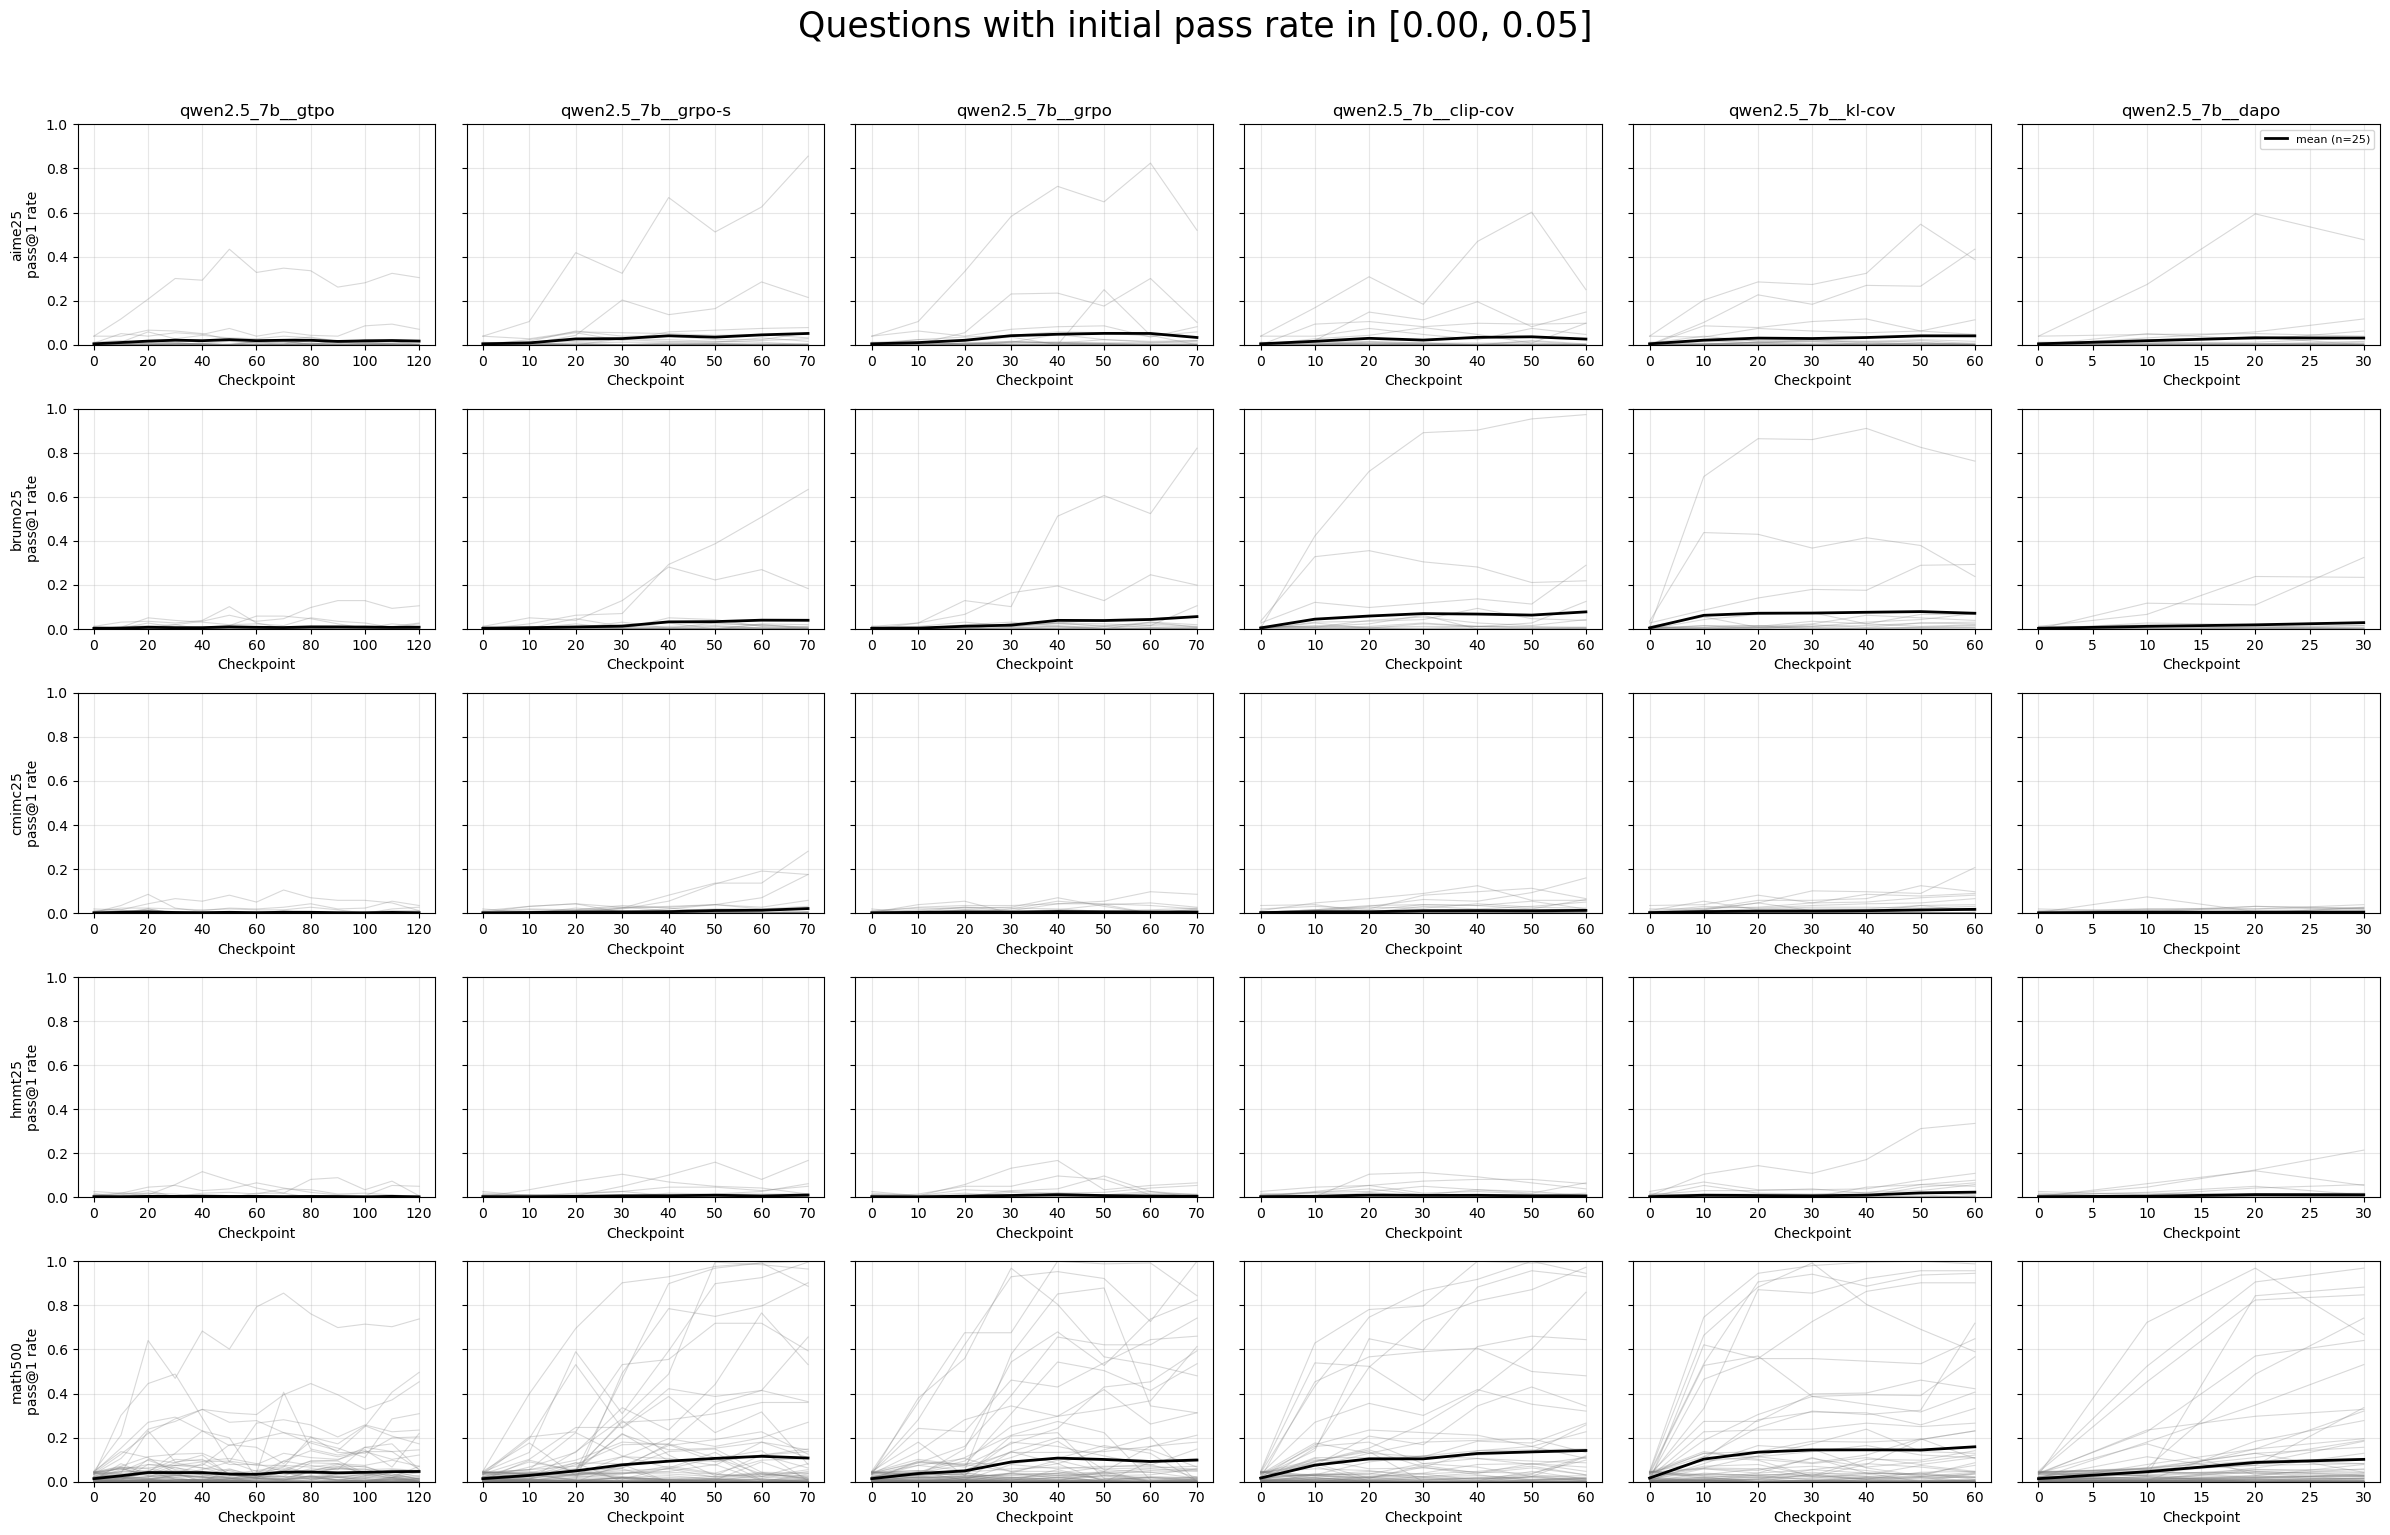

In [11]:
def plot_per_question_dynamics_filtered(per_question_passrates, low_thresh=0.0, high_thresh=0.05):
    """
    Plot per-question learning curves filtered by initial success rate range.

    Args:
        per_question_passrates: dict[method][checkpoint][dataset] -> np.array of per-question pass rates
        low_thresh: float, minimum initial pass rate to include
        high_thresh: float, maximum initial pass rate to include
    """
    methods = list(per_question_passrates.keys())
    n_methods = len(methods)

    # Collect all dataset names
    datasets = sorted({
        ds for method_data in per_question_passrates.values()
        for ckpt_data in method_data.values()
        for ds in ckpt_data.keys()
    })
    n_datasets = len(datasets)

    fig, axes = plt.subplots(
        n_datasets, n_methods,
        figsize=(4 * n_methods, 3 * n_datasets),
        sharey='row',
        squeeze=False
    )

    for j, method in enumerate(methods):
        method_data = per_question_passrates[method]
        checkpoints = sorted(method_data.keys(), key=lambda x: int(x))
        ckpt_nums = [int(c) for c in checkpoints]

        for i, dataset in enumerate(datasets):
            ax = axes[i, j]

            # Skip if missing
            if dataset not in method_data.get(checkpoints[0], {}):
                ax.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax.transAxes)
                continue

            # Select questions within the threshold range at the first checkpoint
            first_ckpt = np.array(method_data[checkpoints[0]][dataset])
            mask = (first_ckpt >= low_thresh) & (first_ckpt <= high_thresh)
            n_selected = mask.sum()

            if n_selected == 0:
                ax.text(0.5, 0.5, "No questions in range", ha='center', va='center', transform=ax.transAxes)
                ax.set_title(method)
                ax.set_xlabel("Checkpoint")
                continue

            # Gather trajectories for selected questions
            per_question_values = []
            for ckpt in checkpoints:
                if dataset in method_data[ckpt]:
                    vals = np.array(method_data[ckpt][dataset])[mask]
                else:
                    vals = np.full(n_selected, np.nan)
                per_question_values.append(vals)

            per_question_values = np.stack(per_question_values, axis=0)  # (n_ckpts, n_selected)

            # Plot trajectories
            ax.plot(
                ckpt_nums,
                per_question_values,
                color='gray',
                alpha=0.3,
                linewidth=0.8
            )

            # Mean curve
            mean_curve = np.nanmean(per_question_values, axis=1)
            ax.plot(
                ckpt_nums,
                mean_curve,
                color='black',
                linewidth=2,
                label=f"mean (n={n_selected})"
            )

            if i == 0:
                ax.set_title(method)
            if j == 0:
                ax.set_ylabel(f"{dataset}\npass@1 rate")

            ax.set_xlabel("Checkpoint")
            ax.set_ylim(0, 1)
            ax.grid(True, alpha=0.3)

            if i == 0 and j == n_methods - 1:
                ax.legend(fontsize=8)

    plt.suptitle(f"Questions with initial pass rate in [{low_thresh:.2f}, {high_thresh:.2f}]",
                 fontsize=25, y=1.02)
    plt.tight_layout()
    plt.show()

plot_per_question_dynamics_filtered(prs_method_question, low_thresh=0, high_thresh=0.05)

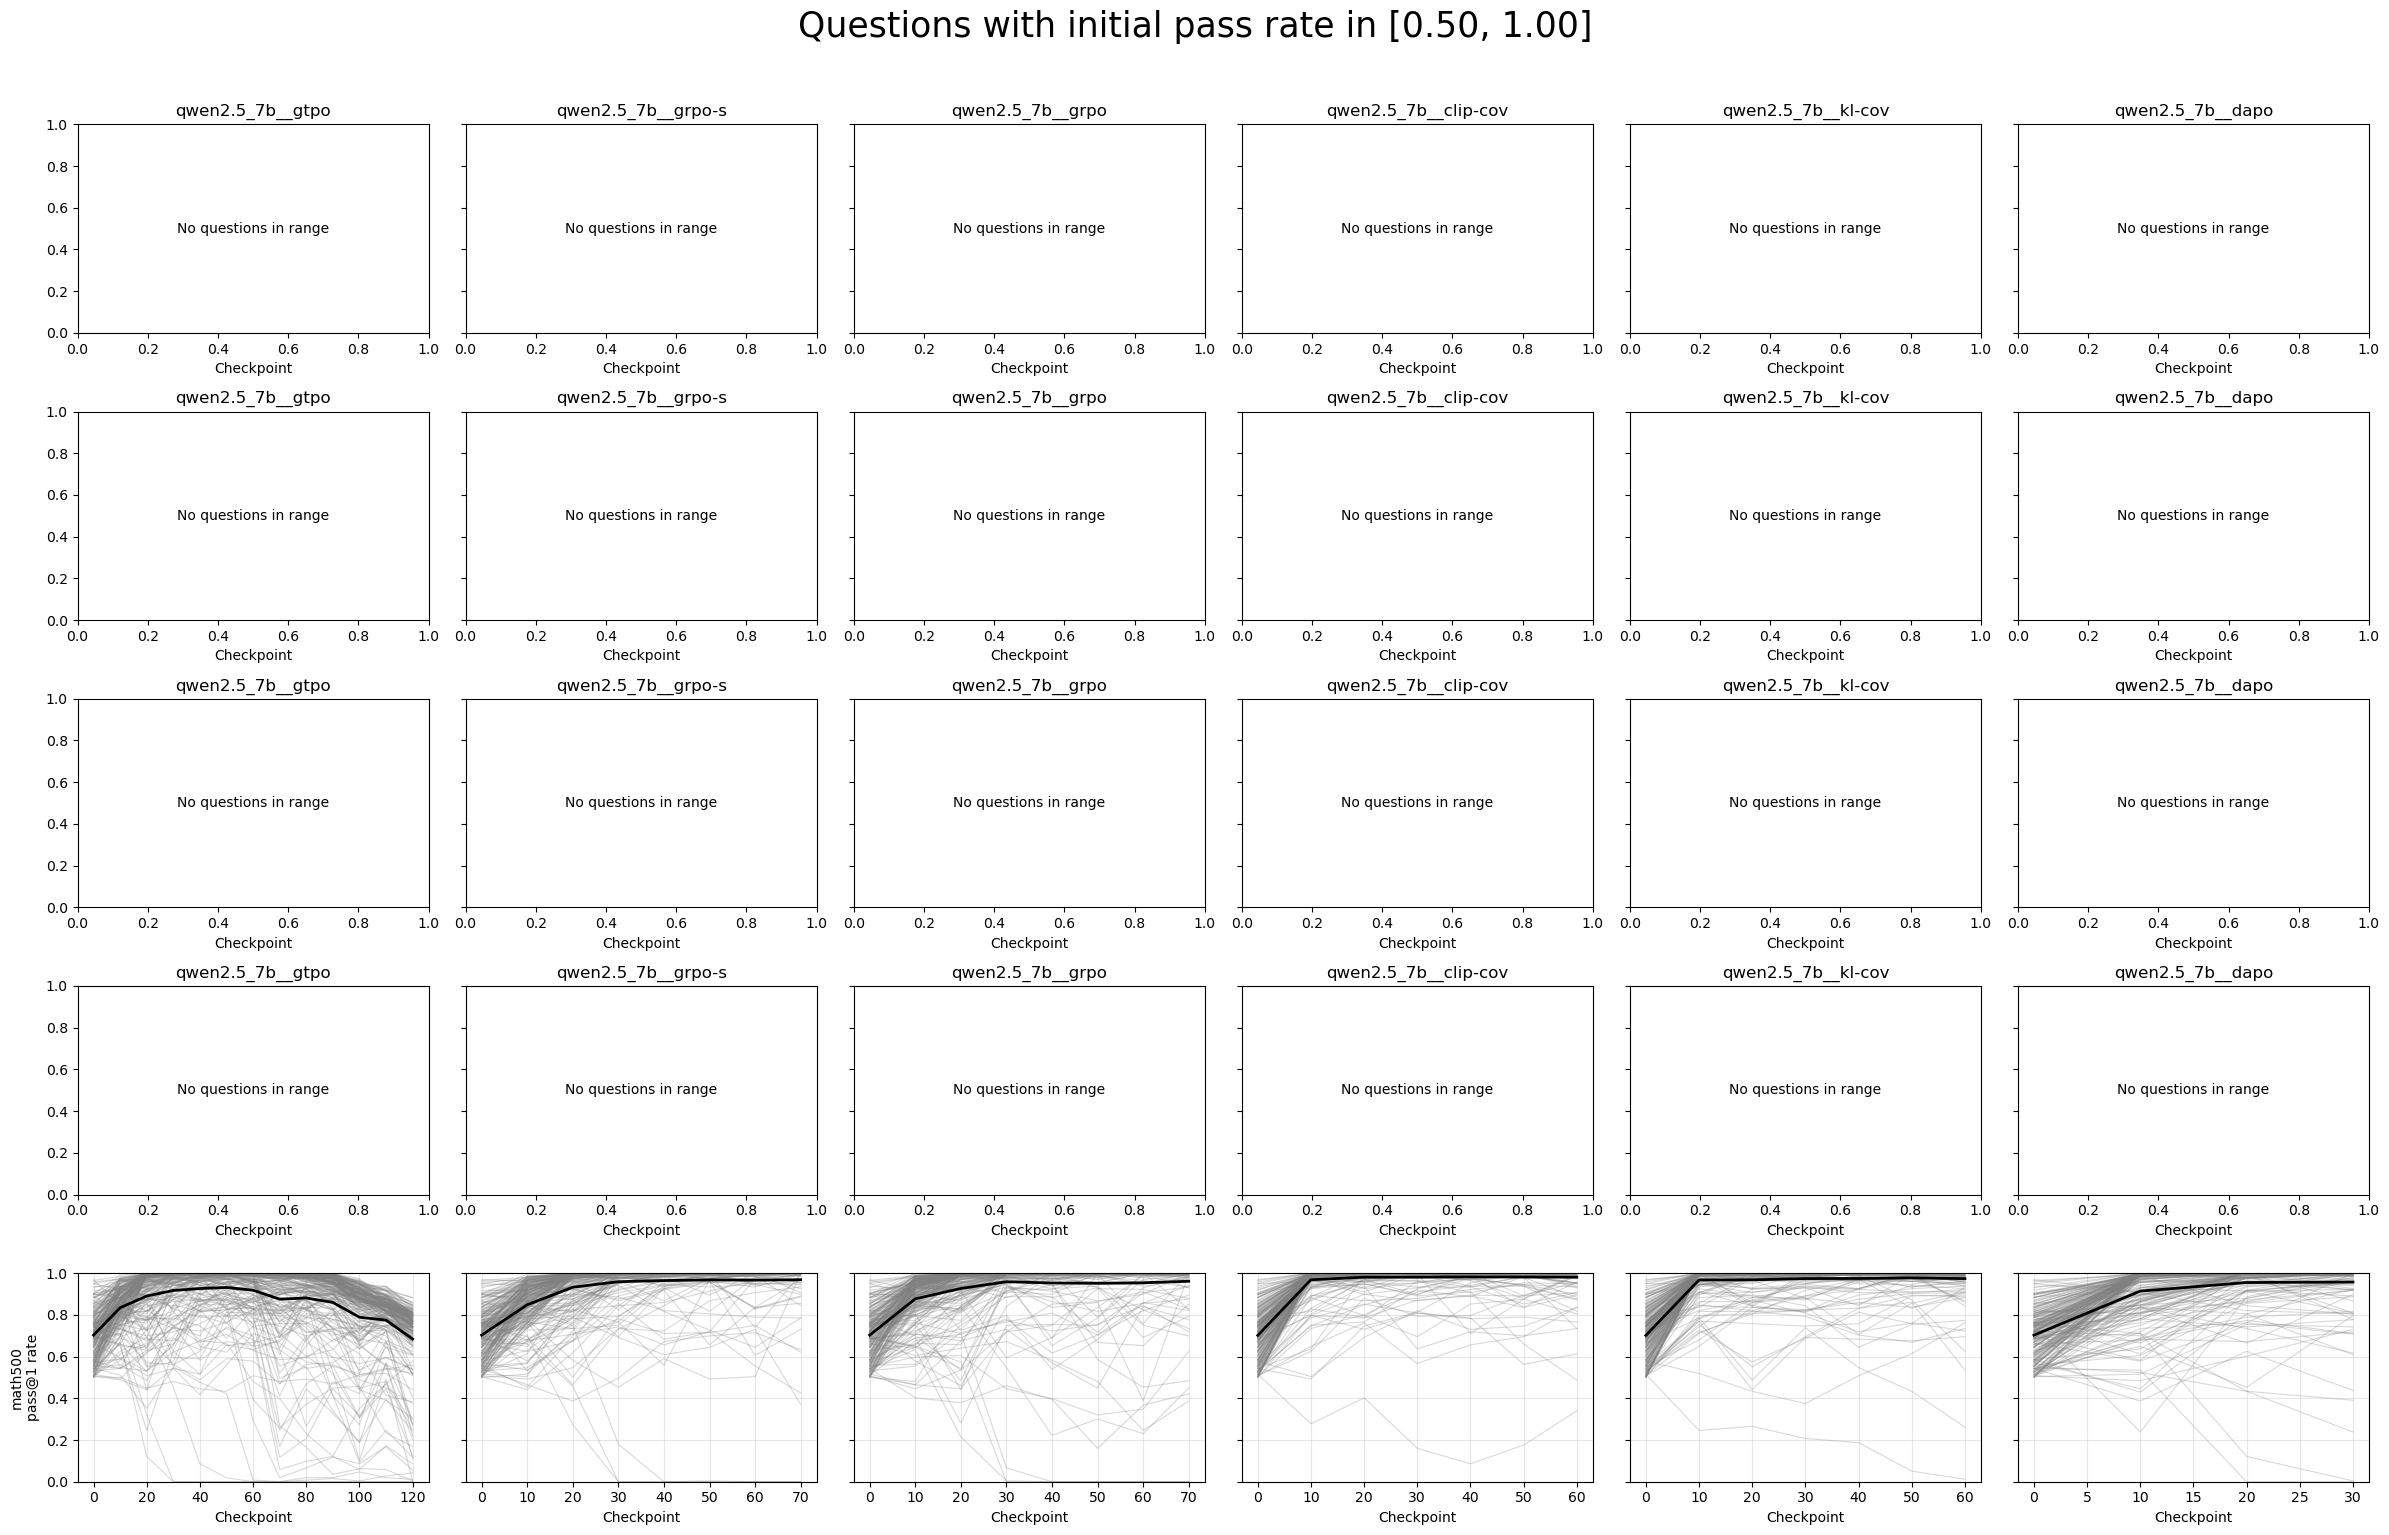

In [12]:
plot_per_question_dynamics_filtered(prs_method_question, low_thresh=0.5, high_thresh=1.0)

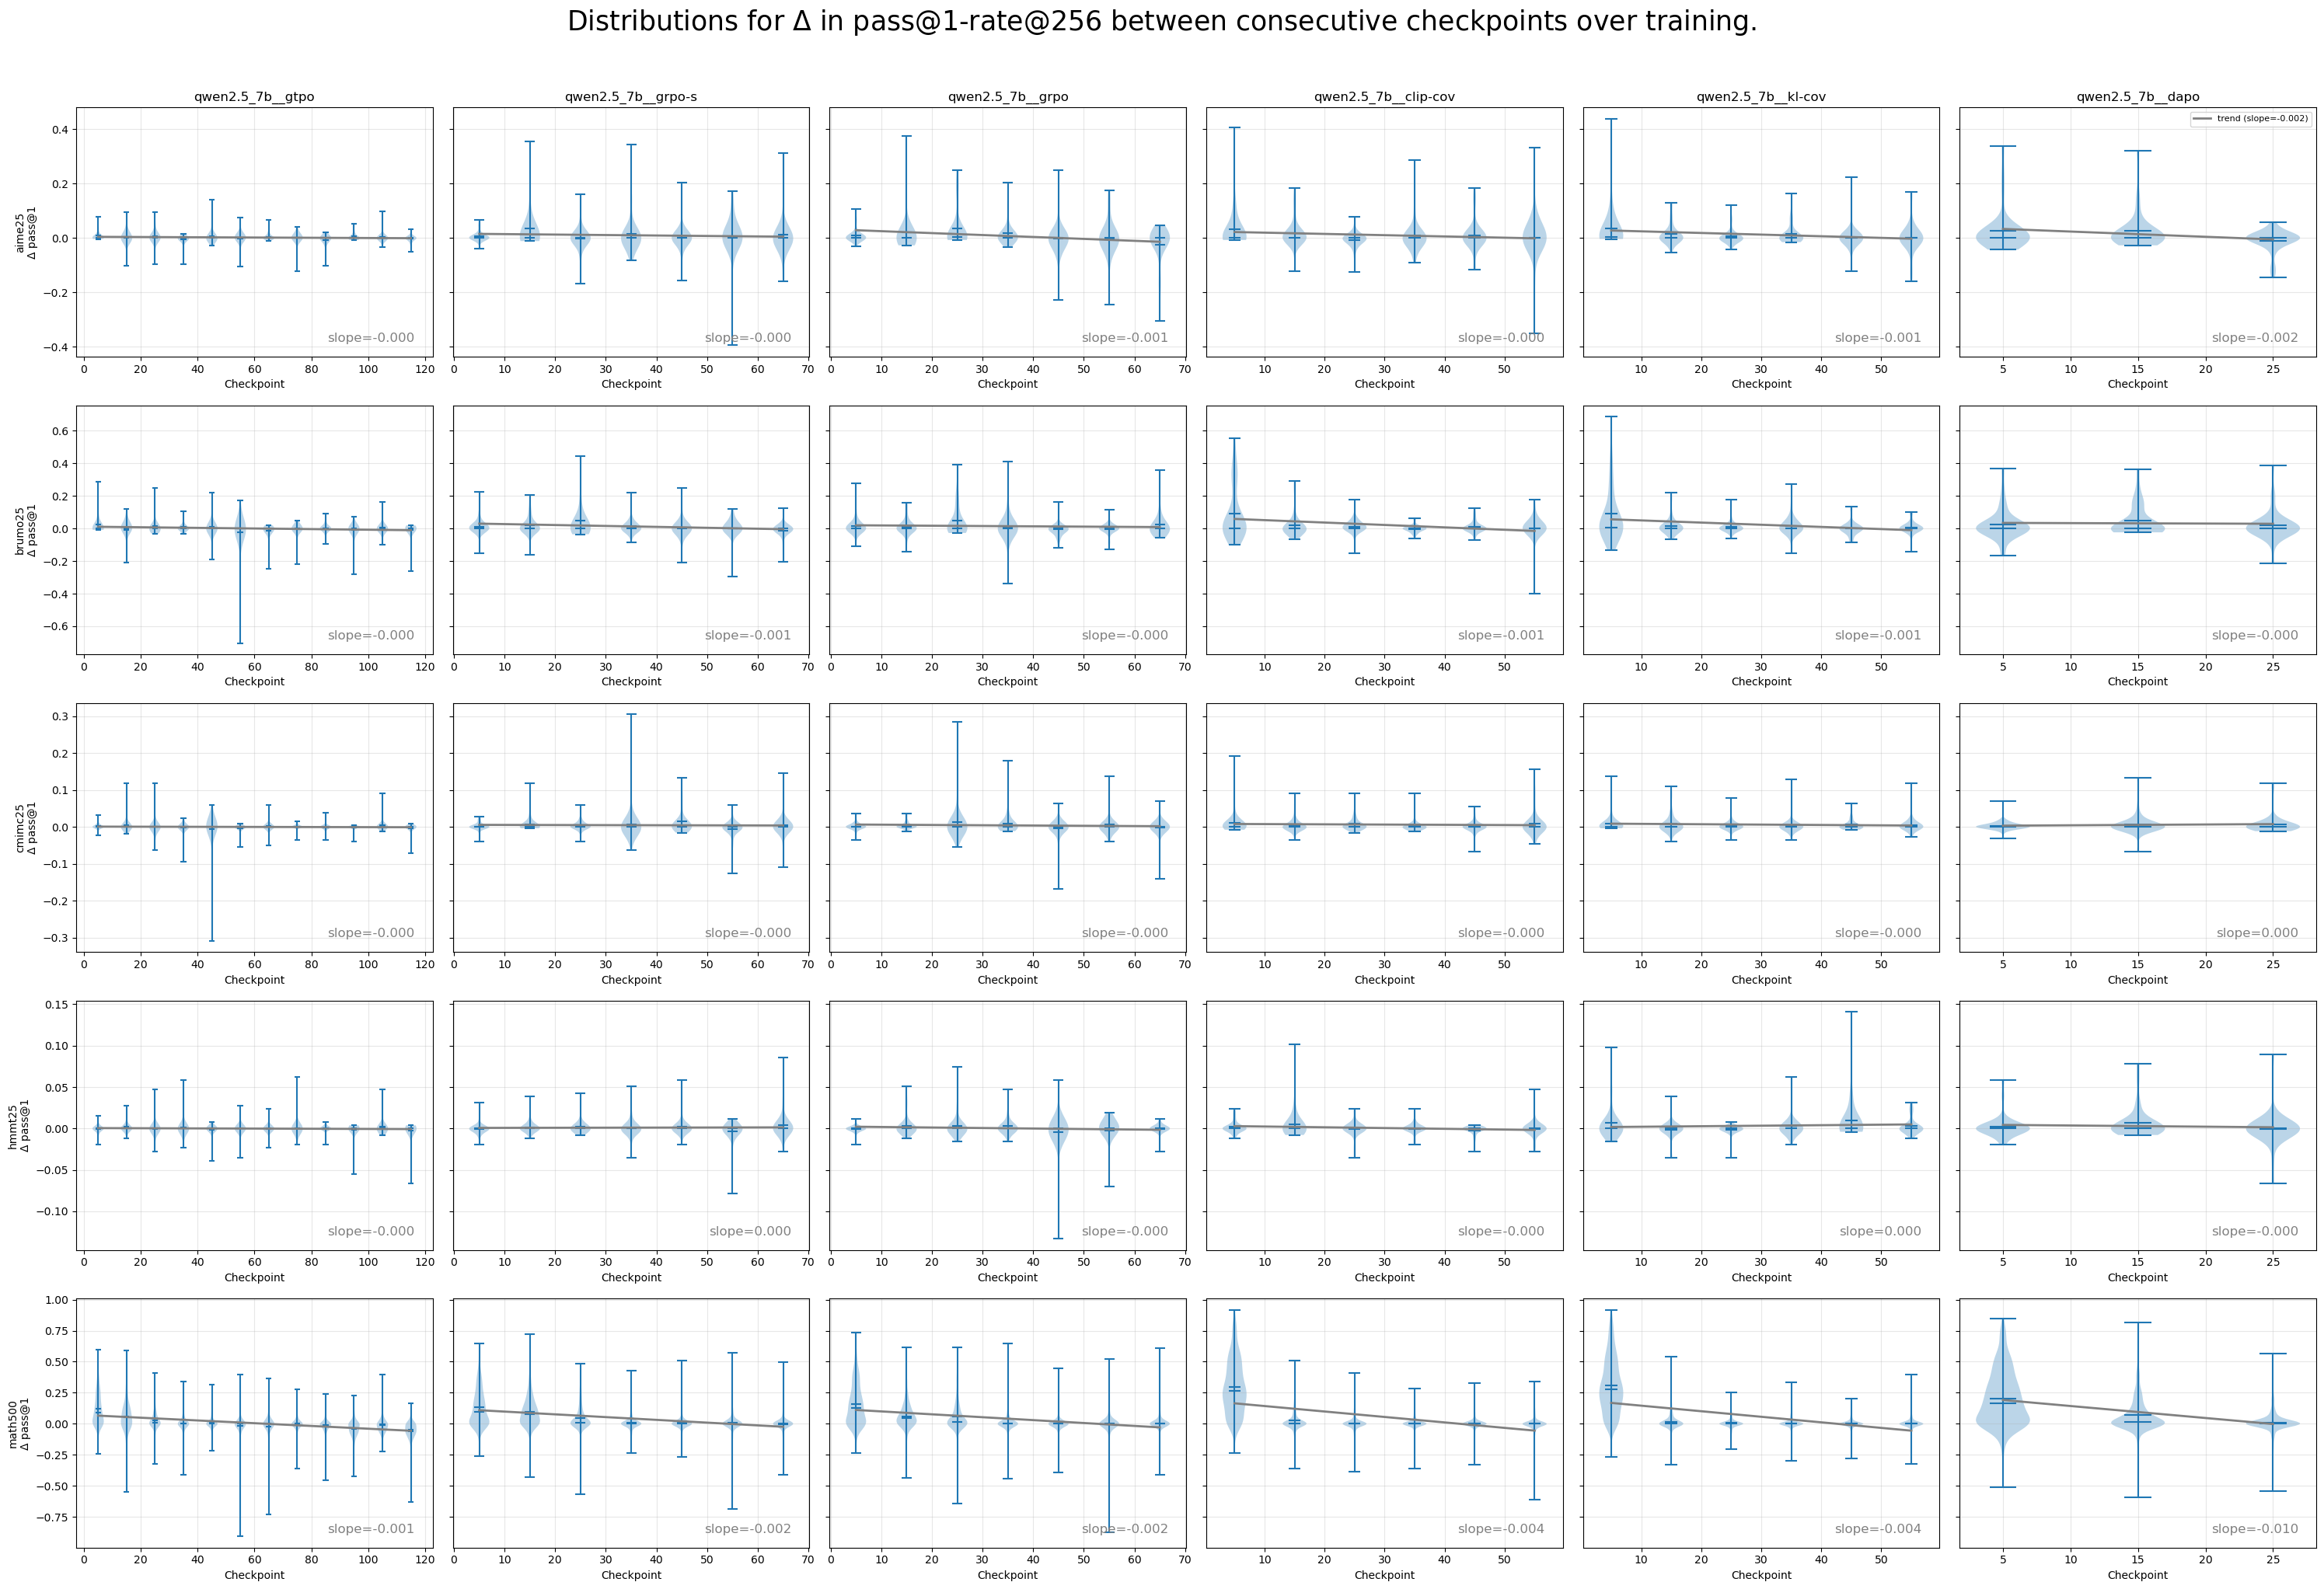

In [13]:
def plot_passrate_deltas_violin_with_trend(per_question_passrates, violin_width=4):
    """
    Plot violin plots of per-question passrate changes between consecutive checkpoints,
    fit a linear trend to the mean Δ passrates, and show the slope.
    
    Args:
        per_question_passrates: dict[method][checkpoint][dataset] -> np.array of per-question pass rates
        violin_width: float, width of each violin
    """
    methods = list(per_question_passrates.keys())
    n_methods = len(methods)

    # Collect all dataset names
    datasets = sorted({
        ds for method_data in per_question_passrates.values()
        for ckpt_data in method_data.values()
        for ds in ckpt_data.keys()
    })
    n_datasets = len(datasets)

    fig, axes = plt.subplots(
        n_datasets, n_methods,
        figsize=(5 * n_methods, 4 * n_datasets),
        squeeze=False,
        sharey='row'
    )

    for j, method in enumerate(methods):
        method_data = per_question_passrates[method]
        checkpoints = sorted(method_data.keys(), key=lambda x: int(x))
        ckpt_nums = [int(c) for c in checkpoints]

        for i, dataset in enumerate(datasets):
            ax = axes[i, j]

            # Stack per checkpoint values (shape: n_ckpts x n_questions)
            values_list = []
            for ckpt in checkpoints:
                if dataset in method_data[ckpt]:
                    values_list.append(np.array(method_data[ckpt][dataset]))
            if len(values_list) < 2:
                ax.text(0.5, 0.5, "Not enough checkpoints", ha='center', va='center', transform=ax.transAxes)
                continue
            values_stack = np.stack(values_list, axis=0)

            # Compute deltas between consecutive checkpoints
            deltas = np.diff(values_stack, axis=0)  # shape: (n_ckpts-1, n_questions)
            deltas = np.clip(deltas, -1, 1)

            # Compute mean Δ for trend fitting
            mean_deltas = np.mean(deltas, axis=1)
            positions = [(ckpt_nums[k] + ckpt_nums[k+1]) / 2 for k in range(len(ckpt_nums)-1)]

            # Plot violin per checkpoint interval
            ax.violinplot(deltas.T, positions=positions, showmeans=True, showmedians=True, widths=violin_width)

            # Fit linear trend to mean Δs
            m, b = np.polyfit(positions, mean_deltas, 1)
            trend_line = m * np.array(positions) + b
            ax.plot(positions, trend_line, color='gray', linewidth=2, label=f"trend (slope={m:.3f})")

            if i == 0:
                ax.set_title(method)
            if j == 0:
                ax.set_ylabel(f"{dataset}\nΔ pass@1")

            ax.set_xlabel("Checkpoint")
            ax.grid(True, alpha=0.3)

            # Annotate slope on subplot
            ax.text(0.95, 0.05, f"slope={m:.3f}", transform=ax.transAxes,
                    horizontalalignment='right', verticalalignment='bottom', color='gray', fontsize=12)

            if i == 0 and j == n_methods - 1:
                ax.legend(fontsize=8)
    plt.suptitle("Distributions for $\Delta$ in pass@1-rate@256 between consecutive checkpoints over training.",
                 fontsize=25, y=1.02)
    plt.tight_layout()
    plt.show()

plot_passrate_deltas_violin_with_trend(prs_method_question, violin_width=4)

In [14]:
from scipy.stats import norm

class KernelDensityEstimator:
    """Simple KDE with reflection at boundaries for [0,1] data"""
    
    def __init__(self, bandwidth=0.05):
        self.bandwidth = bandwidth
        self.data = None
    
    def fit(self, X):
        self.data = X.flatten()
        return self
    
    def pdf(self, x):
        """Compute PDF using reflection method for boundaries"""
        if self.data is None:
            return np.zeros_like(x)
        
        pdf = np.zeros_like(x)
        h = self.bandwidth
        
        for xi in self.data:
            # Original kernel
            pdf += norm.pdf(x, xi, h)
            
            # Reflection at x=0
            pdf += norm.pdf(x, -xi, h)
            
            # Reflection at x=1
            pdf += norm.pdf(x, 2-xi, h)
        
        pdf /= len(self.data)
        return pdf


def fit_kde_distribution(data):
    """Fit KDE distribution and return results"""
    results = {}
    
    # Kernel Density Estimation with boundary reflection
    try:
        # Choose bandwidth using Silverman's rule of thumb
        n = len(data)
        std_data = np.std(data)
        bandwidth = 1.06 * std_data * n**(-1/5)
        bandwidth = max(min(bandwidth, 0.1), 0.01)  # Constrain bandwidth
        
        kde = KernelDensityEstimator(bandwidth=bandwidth)
        kde.fit(data)
        results['kde'] = {
            'model': kde,
            'name': f'KDE (h={bandwidth:.3f})',
            'bandwidth': bandwidth
        }
    except Exception as e:
        print(f"KDE failed: {e}")
        # Fallback to histogram if KDE fails
        try:
            hist, bin_edges = np.histogram(data, bins=15, density=True)
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            results['histogram'] = {
                'hist': hist,
                'bin_centers': bin_centers,
                'bin_edges': bin_edges,
                'name': 'Histogram (fallback)'
            }
        except Exception as e2:
            print(f"Histogram fallback also failed: {e2}")
    
    return results

def plot_final_delta_distributions(per_question_passrates, n_points=100):
    """
    Plot KDE/histogram of per-question passrate changes between first and last checkpoints,
    per method and per dataset.
    
    Args:
        per_question_passrates: dict[method][checkpoint][dataset] -> np.array of per-question pass rates
        n_points: int, number of points for plotting KDE
    """
    methods = list(per_question_passrates.keys())
    n_methods = len(methods)

    # Collect all dataset names
    datasets = sorted({
        ds for method_data in per_question_passrates.values()
        for ckpt_data in method_data.values()
        for ds in ckpt_data.keys()
    })
    n_datasets = len(datasets)

    fig, axes = plt.subplots(
        n_datasets, n_methods,
        figsize=(5 * n_methods, 4 * n_datasets),
        squeeze=True,
        sharex=False,
        sharey=True
    )

    for j, method in enumerate(methods):
        method_data = per_question_passrates[method]
        checkpoints = sorted(method_data.keys(), key=lambda x: int(x))
        first_ckpt = checkpoints[0]
        last_ckpt = checkpoints[-1]

        for i, dataset in enumerate(datasets):
            ax = axes[i, j]

            if dataset not in method_data.get(first_ckpt, {}) or dataset not in method_data.get(last_ckpt, {}):
                ax.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax.transAxes)
                continue

            delta = np.array(method_data[last_ckpt][dataset]) - np.array(method_data[first_ckpt][dataset])
            delta = np.clip(delta, -1, 1)  # ensure Δ is within [-1,1]

            # Fit KDE or fallback histogram
            results = fit_kde_distribution(delta)

            x = np.linspace(-1, 1, n_points)

            if 'kde' in results:
                kde = results['kde']['model']
                y = kde.pdf(x)
                ax.plot(x, y, color='blue', lw=2, label=f"KDE (h={results['kde']['bandwidth']:.3f})")
            elif 'histogram' in results:
                hist = results['histogram']['hist']
                bin_centers = results['histogram']['bin_centers']
                ax.bar(bin_centers, hist, width=(bin_centers[1]-bin_centers[0]), color='blue', alpha=0.6, label='Histogram')

            ax.set_title(method if i==0 else "")
            if j == 0:
                ax.set_ylabel(f"{dataset}\nDensity")
            ax.set_xlabel("Δ pass@1 (last - first)")
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=8)

    plt.suptitle("Per-question Δ passrate distributions (first -> last checkpoint)", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

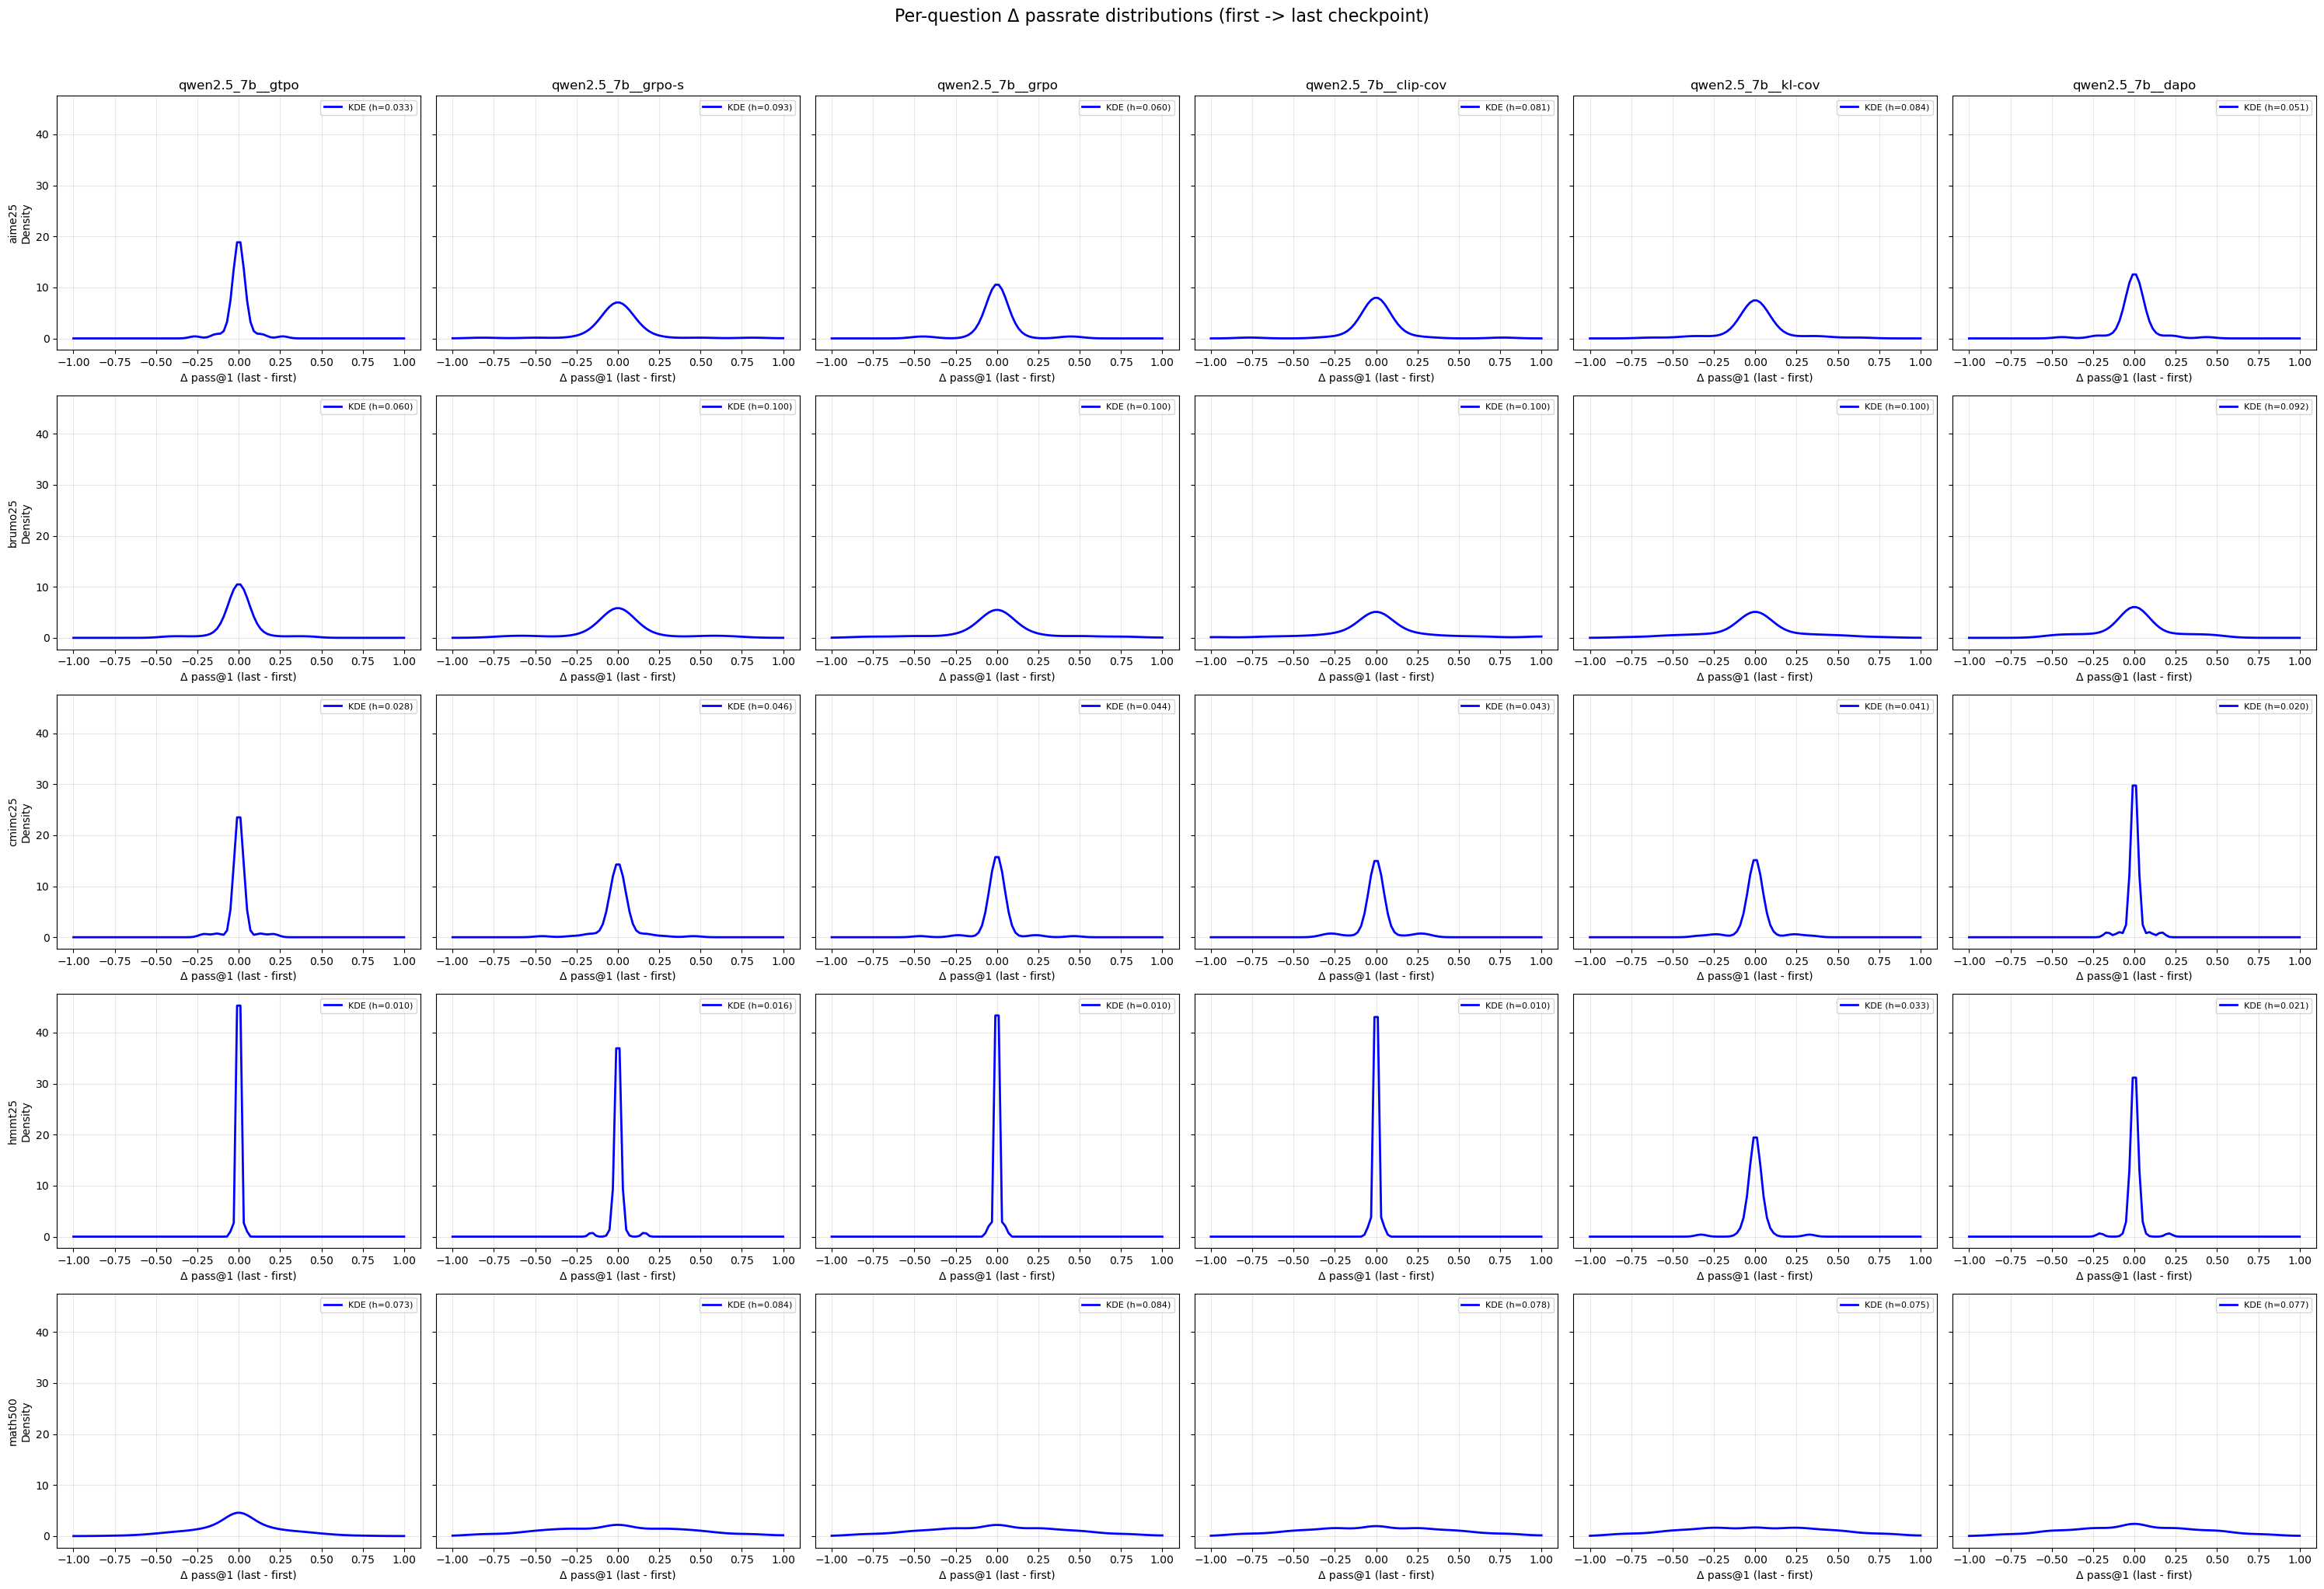

In [15]:
plot_final_delta_distributions(prs_method_question)

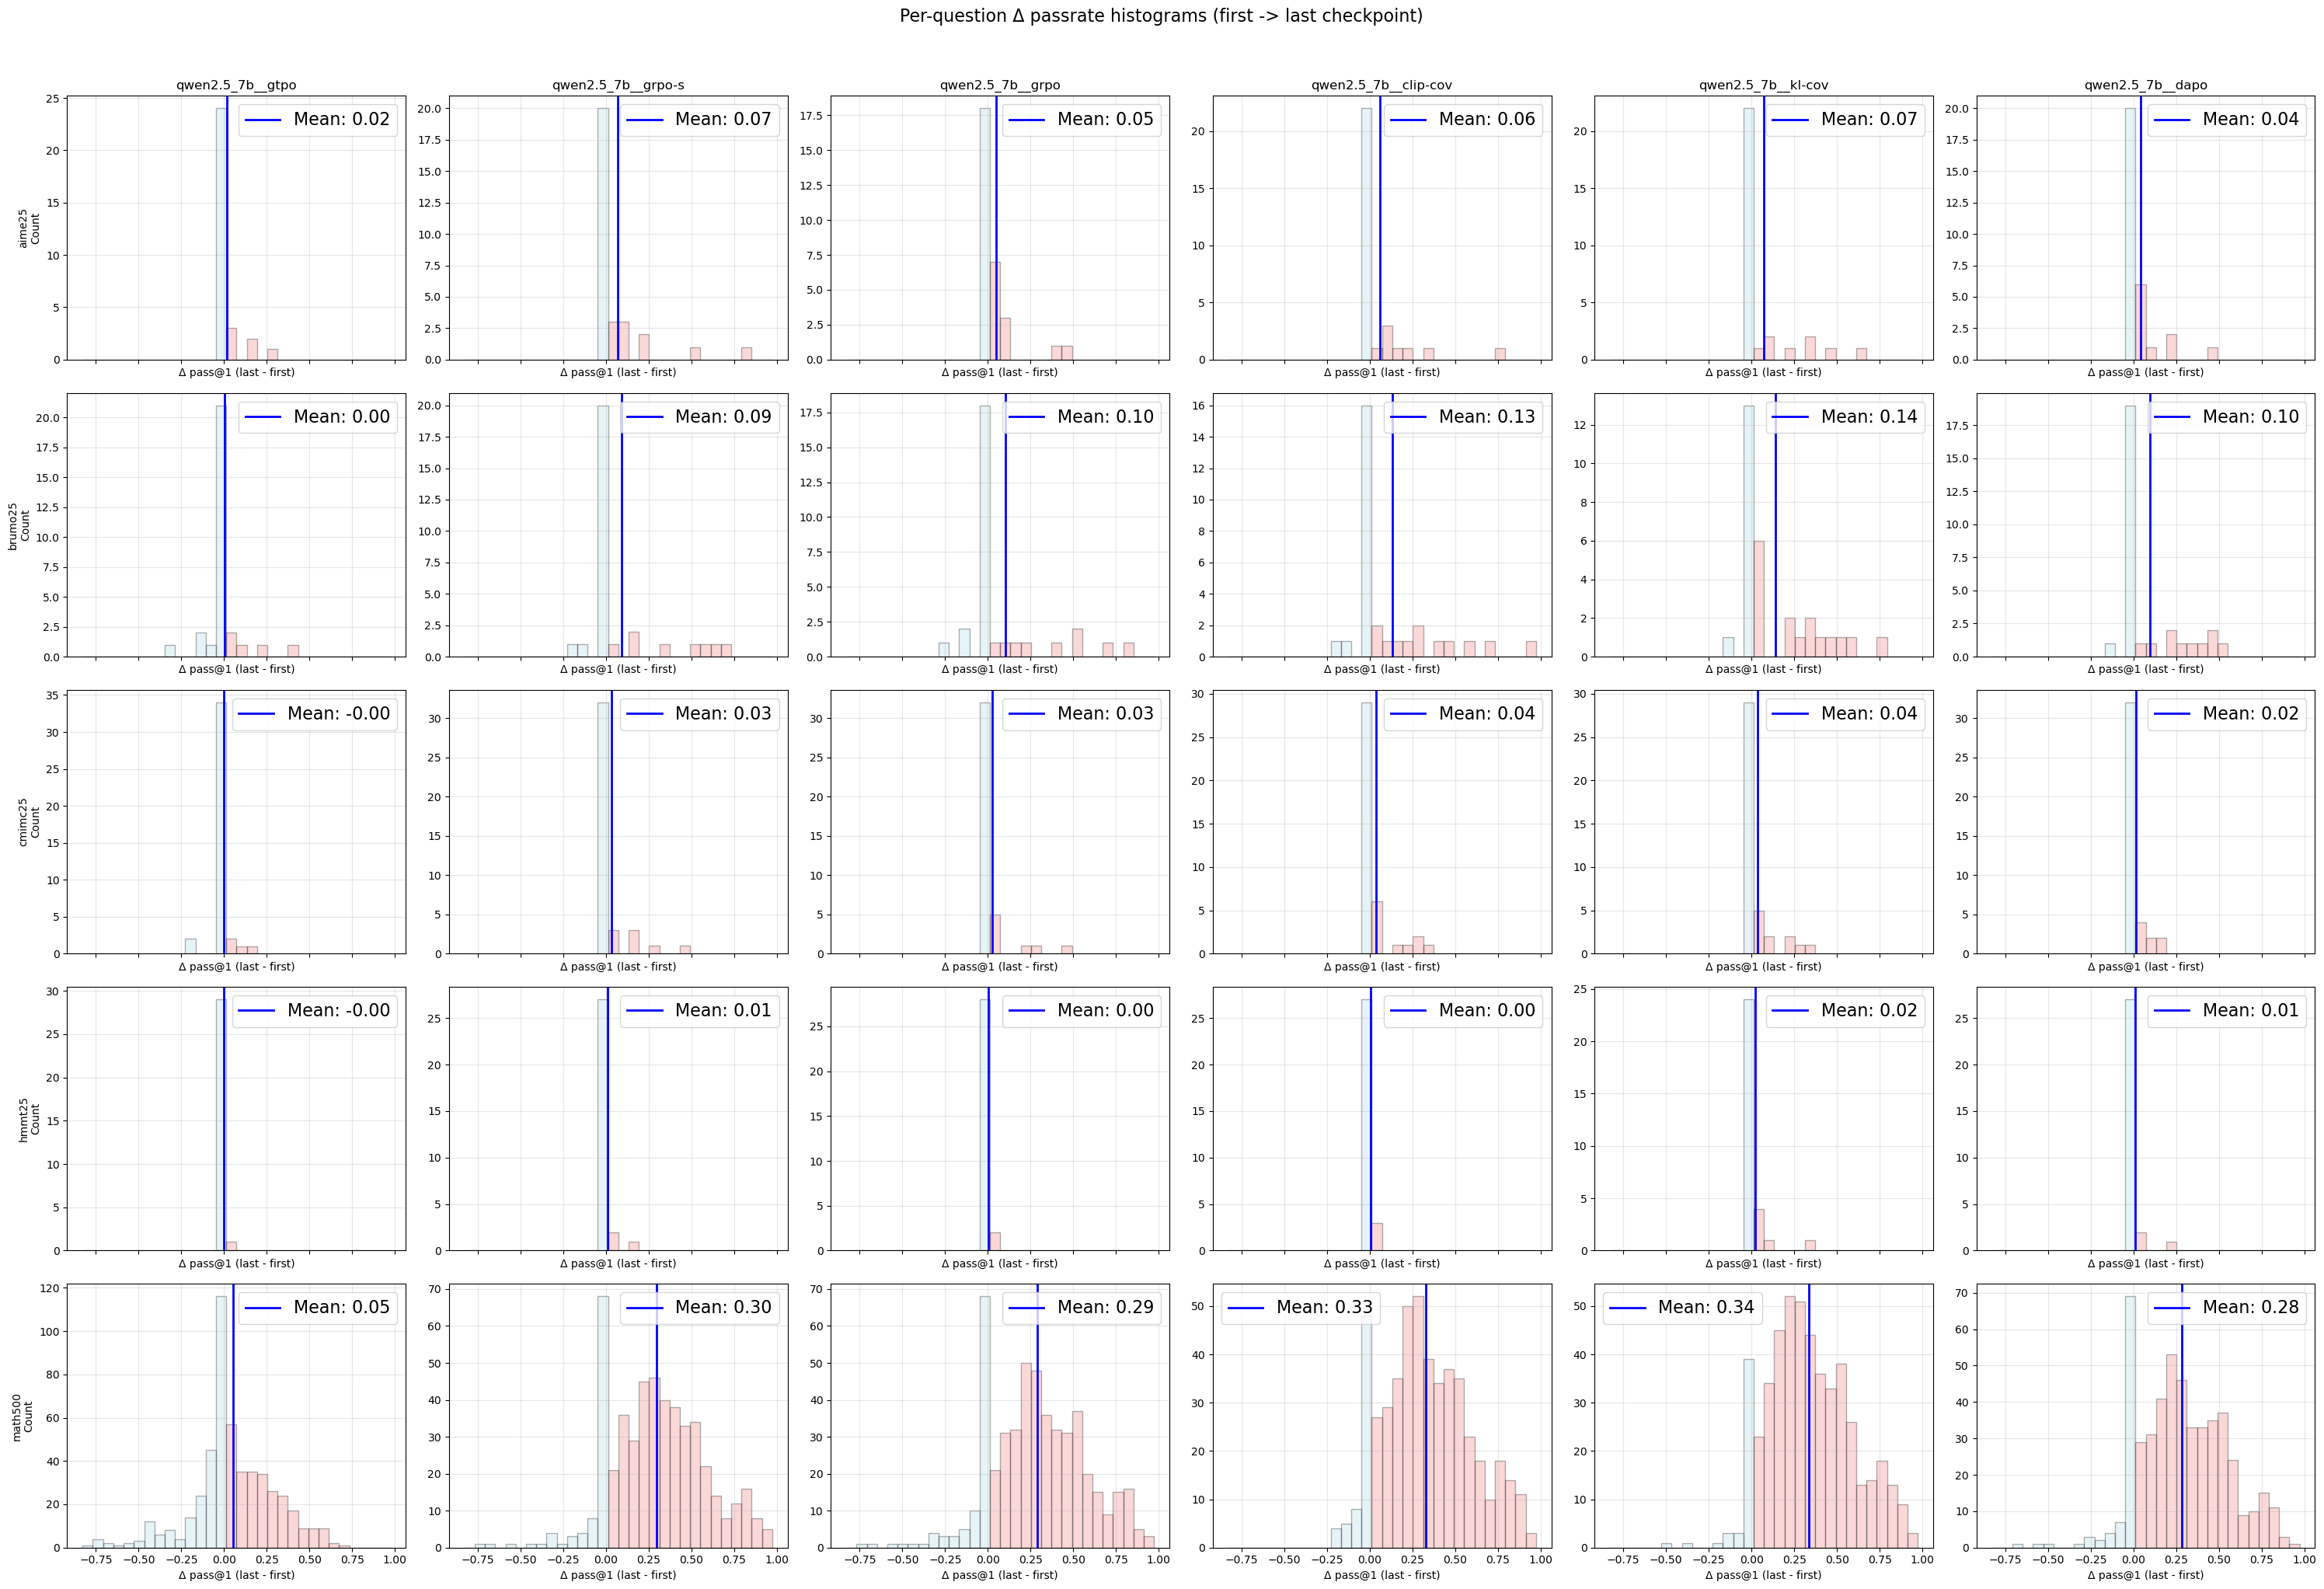

In [16]:
import numpy as np
def plot_final_delta_histograms(per_question_passrates, bins=30):
    """
    Plot histograms of per-question passrate changes between first and last checkpoint,
    per method and per dataset, with consistent bins across all subplots.
    
    Args:
        per_question_passrates: dict[method][checkpoint][dataset] -> np.array of per-question pass rates
        bins: int, number of histogram bins
    """
    methods = list(per_question_passrates.keys())
    n_methods = len(methods)

    # Collect all dataset names
    datasets = sorted({
        ds for method_data in per_question_passrates.values()
        for ckpt_data in method_data.values()
        for ds in ckpt_data.keys()
    })
    n_datasets = len(datasets)

    # Compute global min/max Δ for consistent binning
    all_deltas = []
    for method in methods:
        method_data = per_question_passrates[method]
        checkpoints = sorted(method_data.keys(), key=lambda x: int(x))
        first_ckpt = checkpoints[0]
        last_ckpt = checkpoints[-1]
        for dataset in datasets:
            if dataset in method_data.get(first_ckpt, {}) and dataset in method_data.get(last_ckpt, {}):
                delta = np.array(method_data[last_ckpt][dataset]) - np.array(method_data[first_ckpt][dataset])
                delta = np.clip(delta, -1, 1)
                all_deltas.append(delta)
    if len(all_deltas) == 0:
        print("No data available to plot")
        return
    all_deltas = np.concatenate(all_deltas)
    vmin, vmax = all_deltas.min(), all_deltas.max()

    # Create subplots
    fig, axes = plt.subplots(
        n_datasets, n_methods,
        figsize=(5 * n_methods, 4 * n_datasets),
        squeeze=False,
        sharex=True,
        sharey=False
    )

    for j, method in enumerate(methods):
        method_data = per_question_passrates[method]
        checkpoints = sorted(method_data.keys(), key=lambda x: int(x))
        first_ckpt = checkpoints[0]
        last_ckpt = checkpoints[-1]

        for i, dataset in enumerate(datasets):
            ax = axes[i, j]

            if dataset not in method_data.get(first_ckpt, {}) or dataset not in method_data.get(last_ckpt, {}):
                ax.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax.transAxes)
                continue

            delta = np.array(method_data[last_ckpt][dataset]) - np.array(method_data[first_ckpt][dataset])
            delta = np.clip(delta, -1, 1)
            mean_delta = np.mean(delta)

            # Custom colored histogram: separate negative and positive bins
            counts, bin_edges = np.histogram(delta, bins=bins, range=(vmin, vmax))

            for k in range(len(counts)):
                left = bin_edges[k]
                right = bin_edges[k+1]
                center = 0.5 * (left + right)

                if center < 0:
                    color = "lightblue"
                elif center > 0:
                    color = "lightcoral"
                else:
                    color = "gray"

                ax.bar(center, counts[k],
                    width=(right - left),
                    align='center',
                    color=color,
                    edgecolor='black',
                    alpha=0.3)

            # Plot vertical line for mean
            line = ax.axvline(mean_delta, color='blue', linewidth=2)

            # Add legend with mean
            ax.legend([line], [f'Mean: {mean_delta:.2f}'], fontsize=16)
            ax.set_title(method if i==0 else "")
            if j == 0:
                ax.set_ylabel(f"{dataset}\nCount")
            ax.set_xlabel("Δ pass@1 (last - first)")
            ax.grid(True, alpha=0.3)

    plt.suptitle("Per-question Δ passrate histograms (first -> last checkpoint)", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
plot_final_delta_histograms(prs_method_question)

In [29]:
def plot_final_delta_heatmaps(per_question_passrates,
                              delta_bins=20,
                              init_bins=20):

    methods = list(per_question_passrates.keys())
    datasets = sorted({
        ds for m in per_question_passrates.values()
        for ck in m.values()
        for ds in ck.keys()
    })

    n_methods = len(methods)
    n_datasets = len(datasets)

    # Fixed ranges
    init_edges = np.linspace(0.0, 1.0, init_bins + 1)

    # Collect global delta range (still shared)
    all_delta = []
    for method in methods:
        method_data = per_question_passrates[method]
        ckpts = sorted(method_data.keys(), key=lambda x: int(x))
        f, l = ckpts[0], ckpts[-1]
        for ds in datasets:
            if ds in method_data.get(f, {}) and ds in method_data.get(l, {}):
                delta = np.array(method_data[l][ds]) - np.array(method_data[f][ds])
                all_delta.append(np.clip(delta, -1, 1))

    delta_edges = np.linspace(
        np.min(np.concatenate(all_delta)),
        np.max(np.concatenate(all_delta)),
        delta_bins + 1
    )

    fig, axes = plt.subplots(
        n_datasets, n_methods,
        figsize=(5 * n_methods, 4 * n_datasets),
        squeeze=False,
        sharex=True,
        sharey=True
    )

    # -------------------------------------------------------
    # Main loop: dataset-wise color normalization
    # -------------------------------------------------------
    for i, dataset in enumerate(datasets):

        dataset_max = 0
        images = []

        for j, method in enumerate(methods):
            ax = axes[i, j]
            method_data = per_question_passrates[method]
            ckpts = sorted(method_data.keys(), key=lambda x: int(x))
            f, l = ckpts[0], ckpts[-1]

            if dataset not in method_data.get(f, {}) or dataset not in method_data.get(l, {}):
                ax.text(0.5, 0.5, "No data", ha="center", va="center",
                        transform=ax.transAxes)
                continue

            init = np.clip(np.array(method_data[f][dataset]), 0, 1)
            delta = np.clip(np.array(method_data[l][dataset]) - init, -1, 1)

            H, _, _ = np.histogram2d(
                init, delta,
                bins=[init_edges, delta_edges]
            )

            dataset_max = max(dataset_max, H.max())

            im = ax.imshow(
                H,
                origin="lower",
                aspect="auto",
                extent=[
                    delta_edges[0], delta_edges[-1],
                    init_edges[0], init_edges[-1]
                ],
                cmap="viridis"
            )

            images.append(im)

            if i == 0:
                ax.set_title(method, fontsize=14)
            if j == 0:
                ax.set_ylabel(f"{dataset}\nInitial pass@1")

            ax.set_xlabel("Δ pass@1 (last − first)")

        # Normalize all heatmaps for this dataset
        for im in images:
            im.set_clim(0, dataset_max)

        # Dataset-specific colorbar
        cbar = fig.colorbar(
            images[0],
            ax=axes[i, :],
            location="right",
            shrink=0.85,
            pad=0.02
        )
        cbar.set_label("Number of questions")

    plt.suptitle(
        "Per-question pass@1 change vs initial performance",
        fontsize=16,
        y=1.02
    )
    plt.show()

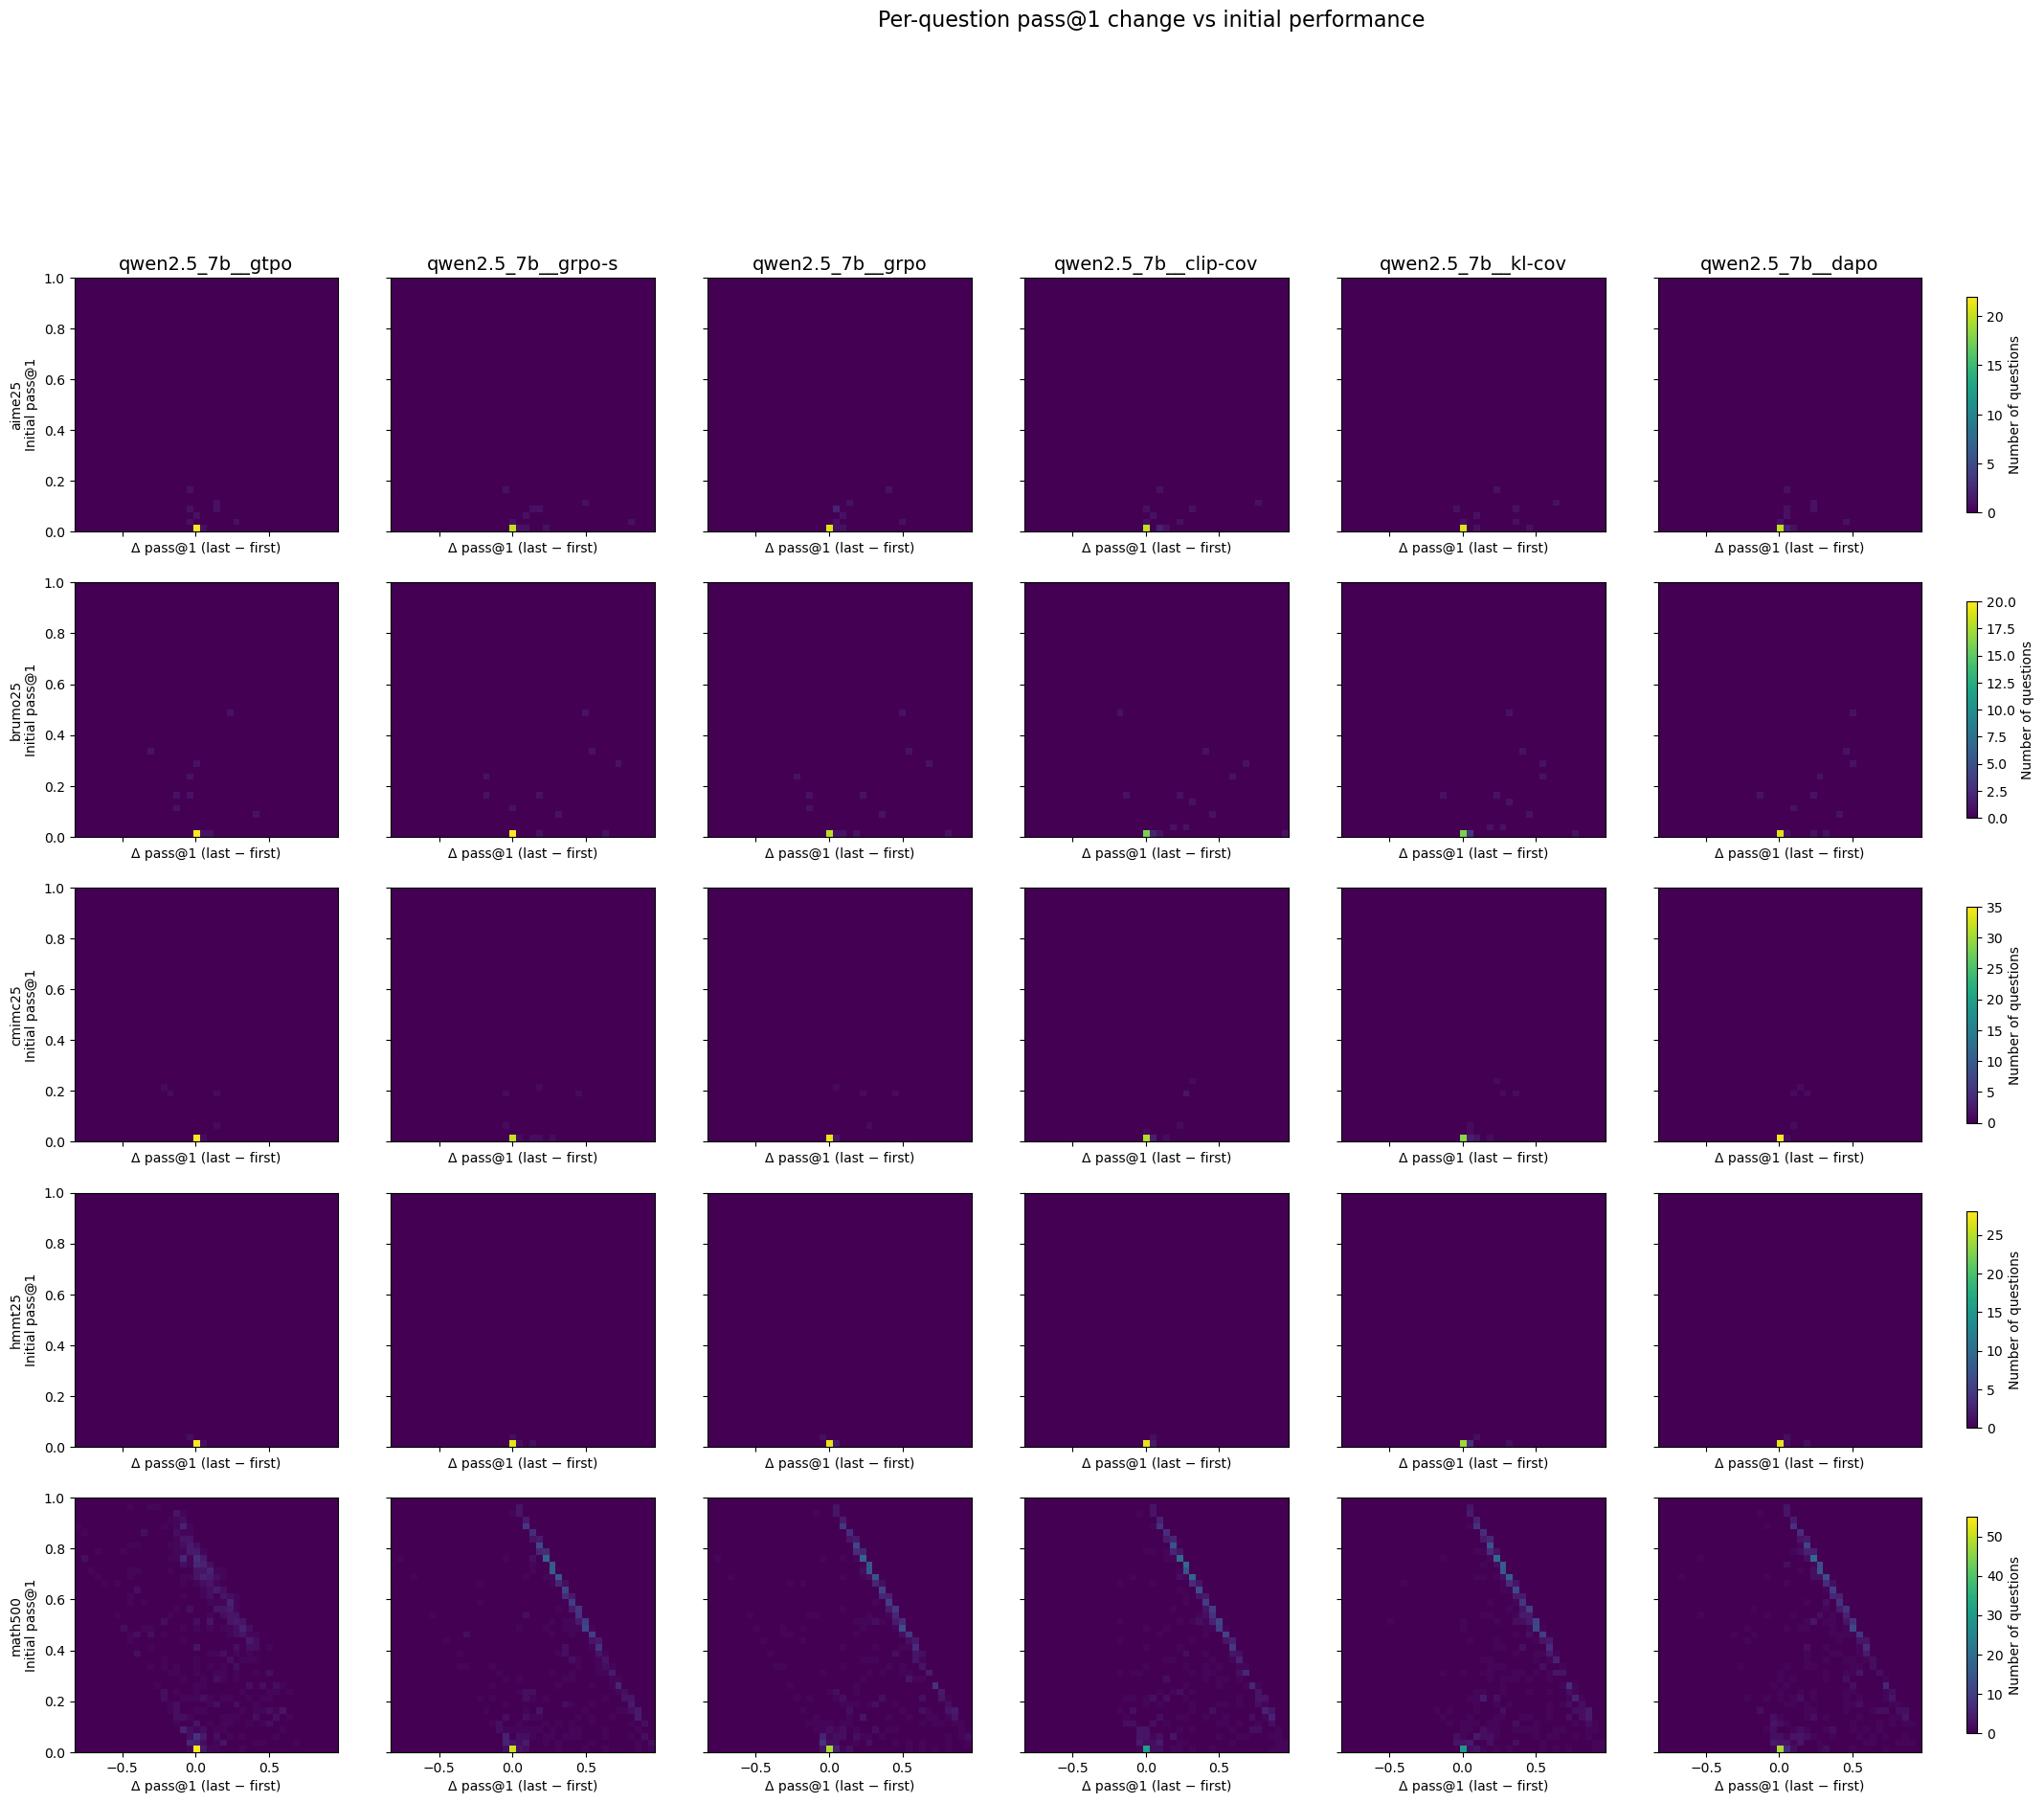

In [31]:
plot_final_delta_heatmaps(prs_method_question, delta_bins=40, init_bins=40)